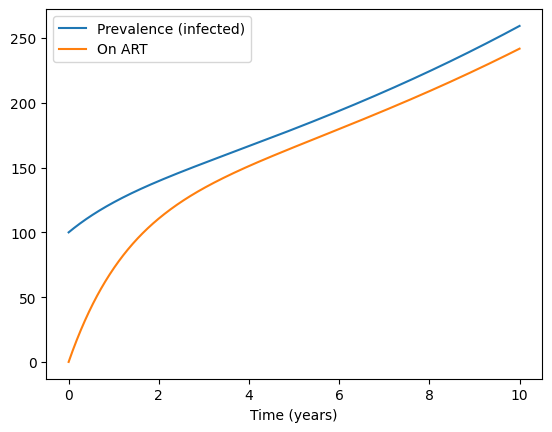

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters (example placeholders — replace with literature values)
beta = 0.0008     # transmission rate per contact * contacts per unit time (placeholder)
gamma = 1/365.0   # rate from infected -> diagnosed/on ART (per day)
mu = 0.0          # natural death/birth (ignored for simplicity)
sigma = 0.2       # relative infectiousness on ART (e.g., 20% of untreated)

# Initial population
N = 10000
I0 = 100
T0 = 0     # on ART
S0 = N - I0 - T0

def deriv(t, y):
    S, I, T = y
    # force of infection: assume homogeneous mixing; T less infectious
    lam = beta * (I + sigma * T) / N
    dSdt = -lam * S
    dIdt = lam * S - gamma * I
    dTdt = gamma * I   # assume all diagnosed start ART immediately
    return [dSdt, dIdt, dTdt]

t_span = (0, 365*10)  # simulate 10 years (days)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
y0 = [S0, I0, T0]

sol = solve_ivp(deriv, t_span, y0, t_eval=t_eval, vectorized=False)
S, I, T = sol.y

plt.plot(sol.t/365, I+T, label='Prevalence (infected)')
plt.plot(sol.t/365, T, label='On ART')
plt.xlabel('Time (years)')
plt.legend()
plt.show()
